In [36]:
%load_ext autoreload
%autoreload 2

from subareas import Subareas
from subarea_calculations import Subarea_Calculations
from sng_bond_simulation import sng_bond_simulation
from mlt_bond_simulation import mlt_bond_simulation
from premium_class import premium_calculations

from climada.hazard import TCTracks, Centroids, TropCyclone
from climada.entity import LitPop
from climada.entity import ImpfSetTropCyclone
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Set CAT Bond Basics

In [20]:
### Bond Basics ###
countries = [659, 388]  # St. Kitts and Nevis
exhaustion_point = 0.5 # 50% of exposure
attachment_point = 0.05 # 5% of exposure
exhaustion_point_method = 'Exposure_Share' # could also be "Return_Period" or None
attachment_point_method = 'Exposure_Share' # could also be "Return_Period" or None
term = 3  # term of bond in years
num_of_terms = 20 # number of terms to simulate
par_index = 60 # statistic for parametric index (e.g. 60 for 60th percentile)

### Subarea Basics ###
resolution_st_kitts = 0.05 # resolution used to derive subareas for St. Kitts and Nevis
resolution_jamaica = 0.5 # resolution used to derive subareas for Jamaica

### Pricing Basics ###
peak_peril = 0 # indicator if bond is considered peak peril (1) or not (0)
hybrid_trigger = 0 # indicator if bond contains a hybrid trigger (1) or not (0)
investment_graded = 0 # indicator if bond is investment graded (1) or not (0)
target_sharpe = 0.5 # target Sharpe ratio for benchmark pricing 
risk_free_rate = 0.0  # risk free rate for Sharpe ratio and simulation of returns

### Define Exposure, Hazard, and Vulnerability

In [16]:
### ST. KITTS AND NEVIS ###
tr_irma = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2017242N16333"
)  # IRMA 2017
tr_irma.equal_timestep()
tr_irma.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.0, 17.5, -62.9, -62.5
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_irma = TropCyclone.from_tracks(tr_irma, centroids=cent)


exp_kit = LitPop.from_countries(
        [str(countries[0])], fin_mode='gdp', reference_year=2020
    )

impfset = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()
iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_kit.gdf.loc[exp_kit.gdf.region_id == countries[0], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_irma.date = np.array([736576, 736596, 736649, 736659, 736668, 736681, 736701, 736702, 736715, 736726,
 736727, 736731, 736743, 736753, 736762, 736781, 736787, 736803, 736808, 736821,
 736843, 736848, 736854, 736868, 736872, 736878, 736892, 736900, 736904, 736912,
 736921, 736926, 736940, 736945, 736952, 736963, 736976, 736983, 736993, 737003,
 737012, 737020, 737031, 737037, 737048, 737059, 737068, 737074, 737081, 737092,
 737098])

2025-11-09 19:34:32,604 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-09 19:34:32,914 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-09 19:34:33,042 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.
2025-11-09 19:34:36,593 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-09 19:34:36,625 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 546 coastal centroids.
2025-11-09 19:34:36,958 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-09 19:34:37,241 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-09 19:34:37,538 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-09 19:34:37,859 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-09 19:34:38,164 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-09

In [ ]:
tr_melissa = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2025291N11319"
)  # IRMA 2017
tr_melissa.equal_timestep()
tr_melissa.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.5, 18.75, -78.5, -76
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_melissa = TropCyclone.from_tracks(tr_melissa, centroids=cent)


exp_jam = LitPop.from_countries(
        [str(countries[1])], fin_mode='gdp', reference_year=2020
    )

iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp_jam.gdf.loc[exp_jam.gdf.region_id == countries[1], 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_melissa.date = np.array([736694, 736774, 736874, 736981, 737013, 737080, 737099, 737155,
       737206, 737297, 737398, 737401, 737482, 737496, 737535, 737576,
       737630, 737677, 737681, 737732, 737765, 737825, 737887, 737937,
       737990, 738024, 738086, 738175, 738278, 738297, 738334, 738390,
       738452, 738536, 738563, 738582, 738633, 738701, 738738, 738795,
       738850, 738884, 738928, 738989, 739062, 739101, 739143, 739193,
       739221, 739268, 739297])

2025-11-09 19:44:24,446 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-09 19:44:24,526 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-09 19:44:24,570 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.
2025-11-09 19:44:27,512 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-09 19:44:27,558 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 7938 coastal centroids.
2025-11-09 19:44:32,440 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-09 19:44:36,945 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-09 19:44:41,782 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-09 19:44:47,088 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-09 19:44:51,542 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-0

### Initialise Subarea Class

2025-11-09 21:31:38,906 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


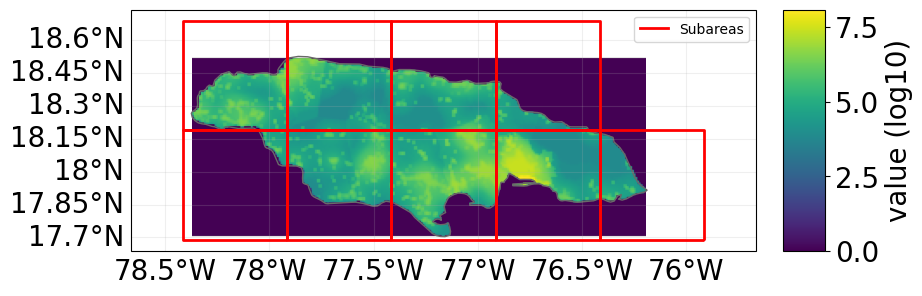

2025-11-09 21:32:01,894 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


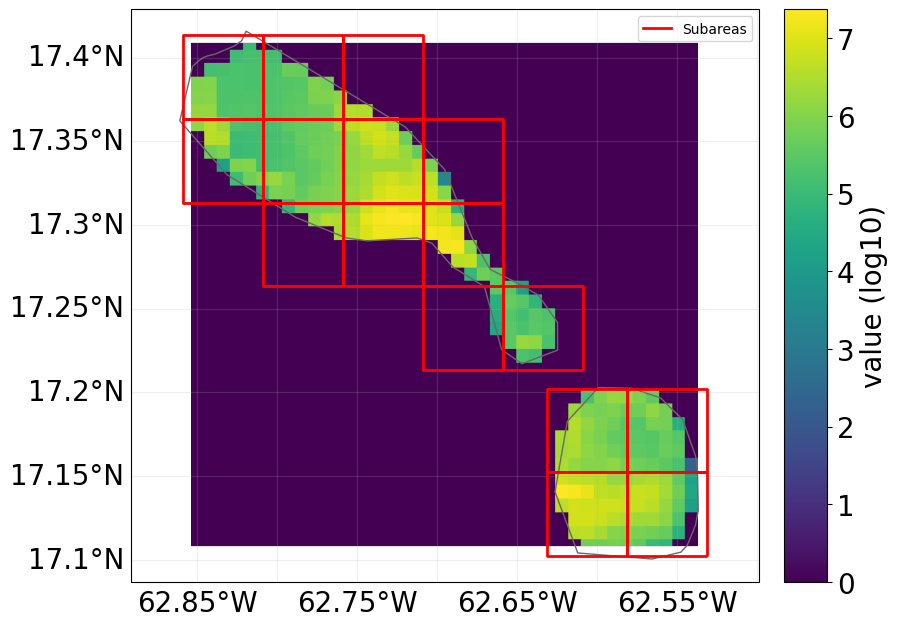

In [67]:
st_kitts_subareas = Subareas(tc_irma, impfset, exp_kit, resolution=resolution_st_kitts)
jamaica_subareas = Subareas(tc_melissa, impfset, exp_jam, resolution=resolution_jamaica)
jamaica_subareas.plot()
st_kitts_subareas.plot()

### Subarea Calculations

In [68]:
st_kitts_sub_calc = Subarea_Calculations(subareas=st_kitts_subareas, index_stat=par_index)
jamaica_sub_calc = Subarea_Calculations(subareas=jamaica_subareas, index_stat=par_index)
st_kitts_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)
jamaica_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)

2025-11-09 21:32:53,817 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for TC
2025-11-09 21:32:53,832 - climada.entity.exposures.base - INFO - Existing centroids will be overwritten for TC
2025-11-09 21:32:53,837 - climada.entity.exposures.base - INFO - Matching 328 exposures with 546 centroids.
2025-11-09 21:32:53,893 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2025-11-09 21:32:53,933 - climada.engine.impact_calc - INFO - Calculating impact for 984 assets (>0) and 51 events.
2025-11-09 21:32:56,095 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for TC
2025-11-09 21:32:56,096 - climada.entity.exposures.base - INFO - Existing centroids will be overwritten for TC
2025-11-09 21:32:56,097 - climada.entity.exposures.base - INFO - Matching 13552 exposures with 7938 centroids.
2025-11-09 21:32:56,145 - climada.util.coordi

### Bond Simulation

In [69]:
### ST. KITTS AND NEVIS BOND SIMULATION ###
st_kitts_bond_sim = sng_bond_simulation(subarea_calc=st_kitts_sub_calc, term=term, number_of_terms=num_of_terms) 
st_kitts_bond_sim.init_loss_simulation()
st_kitts_premiums = premium_calculations(bond_simulation_class=st_kitts_bond_sim)
st_kitts_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
st_kitts_premiums.calc_ibrd_premium()
st_kitts_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
st_kitts_bond_sim.init_return_simulation(premium=st_kitts_premiums.chatoro_prem_rate)
display(st_kitts_bond_sim.return_metrics)
display(st_kitts_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(st_kitts_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(st_kitts_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(st_kitts_premiums.ibrd_prem_rate*100,1)}")

{'annual_premiums': array([8.06426380e-02, 2.48154941e-03, 4.73324946e-18, 7.10555351e-03,
        0.00000000e+00, 0.00000000e+00, 7.10555351e-03, 0.00000000e+00,
        0.00000000e+00, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.52666421e-02, 8.52666421e-02,
        8.52666421e-02, 8.52666421e-02, 8.526

{'EL_ann': 0.017543859649122806,
 'AP_ann': 0.023391812865497075,
 'Tot_payout': 1325883333.3333325,
 'Tot_damages': 11037139919.100546,
 'VaR_99_ann': 0.7555314181864904,
 'VaR_95_ann': 0.0,
 'ES_99_ann': 1.0,
 'ES_95_ann': 0.75}

Benchmark Sharpe Ratio premium rate: 8.7
Chatoro premium rate: 8.5
IBRD premium rate: 5.0


In [70]:
### JAMAICA BOND SIMULATION ###
jamaica_bond_sim = sng_bond_simulation(subarea_calc=jamaica_sub_calc, term=term, number_of_terms=num_of_terms) 
jamaica_bond_sim.init_loss_simulation()
jamaica_premiums = premium_calculations(bond_simulation_class=jamaica_bond_sim)
jamaica_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger)
jamaica_premiums.calc_ibrd_premium()
jamaica_premiums.calc_benchmark_premium(target_sharpe = target_sharpe)
jamaica_bond_sim.init_return_simulation(premium=jamaica_premiums.chatoro_prem_rate)
display(jamaica_bond_sim.return_metrics)
display(jamaica_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(jamaica_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(jamaica_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(jamaica_premiums.ibrd_prem_rate*100,1)}")

{'annual_premiums': array([9.82169321e-02, 8.13626244e-02, 7.03841971e-02, 9.72188933e-02,
        8.62404660e-02, 8.62404660e-02, 9.82169321e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.82169321e-02, 9.65033813e-02,
        9.82169321e-02, 9.65033813e-02, 8.68177195e-02, 9.65033813e-02,
        8.68177195e-02, 5.87201365e-02, 9.70990243e-02, 6.82189176e-02,
        1.48503588e-04, 8.16338116e-02, 2.38431925e-03, 2.72606749e-18,
        3.01111648e-02, 1.64900113e-02, 1.64900113e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.82169321e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.82169321e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.82169321e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.82169321e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.82169321e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.82169321e-02, 9.82169321e-02,
        9.82169321e-02, 9.82169321e-02, 9.821

{'EL_ann': 0.02680332628076214,
 'AP_ann': 0.08771929824561403,
 'Tot_payout': 31653711605.811665,
 'Tot_damages': 50919862874.32074,
 'VaR_99_ann': 0.8387774672602343,
 'VaR_95_ann': 0.12926162262991353,
 'ES_99_ann': 0.8543436945180888,
 'ES_95_ann': 0.4462644805505158}

Benchmark Sharpe Ratio premium rate: 9.8
Chatoro premium rate: 9.8
IBRD premium rate: 6.0


In [71]:
mlt_cat_bond = mlt_bond_simulation(subarea_calc_list=[st_kitts_sub_calc, jamaica_sub_calc], countries_list=countries, term=term,number_of_terms=num_of_terms, tranches=[50,100])
mlt_cat_bond.init_loss_simulation(principal=6000000000, confidence_levels=[0.95,0.99])